In [1]:
# 1: Mount Drive and Load All Song Files
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PATH = "/content/drive/My Drive/mbti_tune_data/data/deduplicated/"
print(f"Loading song files from {DATA_PATH}")

# Load all 16 personality CSV files
all_songs = []
for csv_file in Path(DATA_PATH).glob("*.csv"):
    personality = csv_file.stem
    df = pd.read_csv(csv_file)
    df['personality'] = personality
    all_songs.append(df)
    print(f"  Loaded {personality}: {len(df)} songs")

df = pd.concat(all_songs, ignore_index=True)
print(f"\nTotal songs: {len(df)}")

Mounted at /content/drive
Loading song files from /content/drive/My Drive/mbti_tune_data/data/deduplicated/
  Loaded ESTP: 1643 songs
  Loaded ENTJ: 1615 songs
  Loaded ESFP: 1757 songs
  Loaded ESTJ: 1577 songs
  Loaded ENFP: 1741 songs
  Loaded ENTP: 1240 songs
  Loaded ENFJ: 2263 songs
  Loaded INFJ: 1952 songs
  Loaded ESFJ: 1788 songs
  Loaded ISTJ: 1937 songs
  Loaded INFP: 3273 songs
  Loaded ISFP: 3915 songs
  Loaded INTJ: 1763 songs
  Loaded ISTP: 1882 songs
  Loaded ISFJ: 2392 songs
  Loaded INTP: 1629 songs

Total songs: 32367


In [2]:
# 2: Add MBTI Dimension Labels to Each Song
mbti_map = {
    'E': ['ENFJ', 'ENFP', 'ENTJ', 'ENTP', 'ESFJ', 'ESFP', 'ESTJ', 'ESTP'],
    'I': ['INFJ', 'INFP', 'INTJ', 'INTP', 'ISFJ', 'ISFP', 'ISTJ', 'ISTP'],
    'N': ['ENFJ', 'ENFP', 'ENTJ', 'ENTP', 'INFJ', 'INFP', 'INTJ', 'INTP'],
    'S': ['ESFJ', 'ESFP', 'ESTJ', 'ESTP', 'ISFJ', 'ISFP', 'ISTJ', 'ISTP'],
    'T': ['ENTJ', 'ENTP', 'ESTJ', 'ESTP', 'INTJ', 'INTP', 'ISTJ', 'ISTP'],
    'F': ['ENFJ', 'ENFP', 'ESFJ', 'ESFP', 'INFJ', 'INFP', 'ISFJ', 'ISFP'],
    'J': ['ENFJ', 'ENTJ', 'ESFJ', 'ESTJ', 'INFJ', 'INTJ', 'ISFJ', 'ISTJ'],
    'P': ['ENFP', 'ENTP', 'ESFP', 'ESTP', 'INFP', 'INTP', 'ISFP', 'ISTP']
}

def get_dimensions(personality):
    return [
        1.0 if personality in mbti_map['E'] else 0.0,
        1.0 if personality in mbti_map['N'] else 0.0,
        1.0 if personality in mbti_map['T'] else 0.0,
        1.0 if personality in mbti_map['J'] else 0.0,
    ]

df['E'] = df['personality'].apply(lambda x: get_dimensions(x)[0])
df['N'] = df['personality'].apply(lambda x: get_dimensions(x)[1])
df['T'] = df['personality'].apply(lambda x: get_dimensions(x)[2])
df['J'] = df['personality'].apply(lambda x: get_dimensions(x)[3])

print(f"Dimension balance:")
for dim in ['E','N','T','J']:
    print(f"  {dim}: {df[dim].mean()*100:.1f}%")

Dimension balance:
  E: 42.1%
  N: 47.8%
  T: 41.0%
  J: 47.2%


In [3]:
# 3: Prepare Features (Same 14 audio features as autoencoder)
audio_features = ['BPM', 'Energy', 'Dance', 'Acoustic', 'Instrumental',
                  'Valence', 'Speech', 'Live', 'Popularity', 'Loud (Db)']

# Check which features exist
available_features = [f for f in audio_features if f in df.columns]
print(f"Using {len(available_features)} features: {available_features}")

# Handle missing values
df[available_features] = df[available_features].fillna(df[available_features].median())

# Prepare X and y
X = df[available_features].values.astype(np.float32)
y = df[['E', 'N', 'T', 'J']].values.astype(np.float32)
sample_weights = df['song_frequency'].values.astype(np.float32)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Using 10 features: ['BPM', 'Energy', 'Dance', 'Acoustic', 'Instrumental', 'Valence', 'Speech', 'Live', 'Popularity', 'Loud (Db)']
X shape: (32367, 10)
y shape: (32367, 4)


In [4]:
# 4: Train/Val/Test Split
X_train, X_temp, y_train, y_temp, w_train, w_temp = train_test_split(
    X, y, sample_weights, test_size=0.3, random_state=42, stratify=df['personality']
)

X_val, X_test, y_val, y_test, w_val, w_test = train_test_split(
    X_temp, y_temp, w_temp, test_size=0.5, random_state=42
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# Normalize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
w_train = torch.tensor(w_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

Train: 22656, Val: 4855, Test: 4856


In [5]:
# 5: Define Song-Level Classifier (Simpler than playlist model)
class SongMBTIClassifier(nn.Module):
    def __init__(self, input_dim):
        super(SongMBTIClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 4)
        )

    def forward(self, x):
        return self.network(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SongMBTIClassifier(X_train.shape[1]).to(device)
print(f"Model has {sum(p.numel() for p in model.parameters()):,} parameters")

Model has 12,324 parameters


Training Song-Level Classifier...
Epoch 20: Train Loss=0.9108, Val Loss=0.7145
Epoch 40: Train Loss=0.9052, Val Loss=0.7130
Epoch 60: Train Loss=0.9011, Val Loss=0.7118
Epoch 80: Train Loss=0.8965, Val Loss=0.7108
Epoch 100: Train Loss=0.8947, Val Loss=0.7109


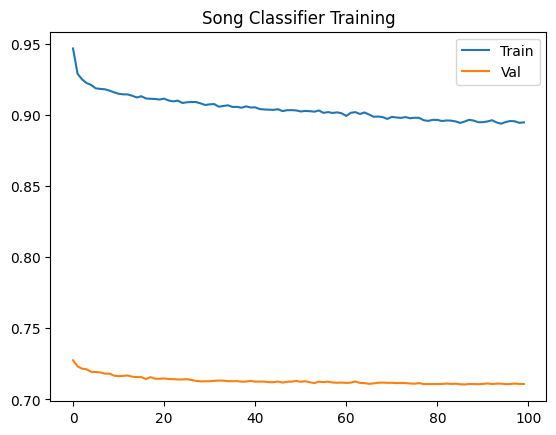

In [6]:
# 6: Train with Frequency Weights
pos_weights = []
for i in range(4):
    n_pos = y_train[:, i].sum().item()
    n_neg = len(y_train) - n_pos
    pos_weights.append(n_neg / n_pos if n_pos > 0 else 1.0)
pos_weights = torch.tensor(pos_weights, device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

batch_size = 256
train_dataset = TensorDataset(X_train, y_train, w_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

epochs = 100
train_losses, val_losses = [], []

print("Training Song-Level Classifier...")
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for bx, by, bw in train_loader:
        bx, by, bw = bx.to(device), by.to(device), bw.to(device)
        optimizer.zero_grad()
        outputs = model(bx)
        loss = (criterion(outputs, by) * bw).mean()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for bx, by in val_loader:
            bx, by = bx.to(device), by.to(device)
            val_loss += criterion(model(bx), by).item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

# Plot
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.legend()
plt.title('Song Classifier Training')
plt.show()

In [7]:
# 7: Evaluate and Export Song Classifier
model.eval()
with torch.no_grad():
    X_test_device = X_test.to(device)
    outputs = model(X_test_device)
    predictions = torch.sigmoid(outputs).cpu().numpy()
    targets = y_test.numpy()

print("\n" + "="*40 + "\nSONG-LEVEL RESULTS\n" + "="*40)
for i, name in enumerate(['E', 'N', 'T', 'J']):
    mae = mean_absolute_error(targets[:, i], predictions[:, i])
    letter_acc = np.mean((predictions[:, i] > 0.5) == (targets[:, i] > 0.5))
    print(f"{name}: MAE={mae:.3f}, Letter Acc={letter_acc:.1%}")

# Save to the central models folder for the Streamlit app[cite: 1]
MODEL_SAVE_PATH = "/content/drive/My Drive/mbti_tune_data/models/song_classifier.pt"
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"\n✅ Song Classifier saved to: {MODEL_SAVE_PATH}")


SONG-LEVEL RESULTS
E: MAE=0.435, Letter Acc=63.4%
N: MAE=0.468, Letter Acc=59.5%
T: MAE=0.442, Letter Acc=63.6%
J: MAE=0.470, Letter Acc=59.4%

✅ Song Classifier saved to: /content/drive/My Drive/mbti_tune_data/models/song_classifier.pt
